### Libraries and Imports


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from datetime import date
%matplotlib inline
from trajectory_video import make_trajectory_video
from trajectory_video2 import make_trajectory_video1
from training_progress_video import make_training_progress_video
import re
import glob
import matplotlib as mpl
import matplotlib.animation as animation
import imageio_ffmpeg
mpl.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()

### PDE and FD reference Parameters and RL action space


In [2]:
# PDE 
alpha = 0.05

#   FD reference grid   
nx    = 50
T     = 1
x_fd  = np.linspace(0.0, 1.0, nx)
dx    = x_fd[1] - x_fd[0]

dt_cfl = 0.45 * dx**2 / alpha
nt     = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt)
dt     = t_fd[1] - t_fd[0]

#  True solution; Analytical diffusion solution

def u_true(x, t):
    return np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * t)

 

### FD For diffusion

In [3]:
def build_fd_reference():
    u = np.zeros((nx, nt))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt / dx**2

    for it in range(nt - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,   it+1] = 0.0
        u[-1,  it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
            bounds_error=False, fill_value=None
    )
    return u, interp

### __ init __

In [4]:
class VisitedSet:

    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._norm          = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every
        self._idx_set       = set()               
        self.rejected_history = []  # (x, t) per rejected move
    def add(self, x, t, u):
        self._idx_set.add((round(x / dx), round(t / dt)))  
        self._pts.append((x, t, u))
        self._norm.append((x / dx, t / dt))
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()
    def _rebuild(self):
        self._tree  = KDTree(np.array(self._norm))
        self._dirty = 0
    def contains(self, x, t):                    
        return (round(x / dx), round(t / dt)) in self._idx_set
    def find_neighbours(self, x_star, t_star, n):
            if len(self._pts) < n:
                return None
            pts_arr  = np.asarray(self._pts)
            norm_arr = np.asarray(self._norm)
            mask = pts_arr[:, 1] < t_star
            if mask.sum() < n:
                return None
            norm_c = norm_arr[mask]
            pts_c  = pts_arr[mask]
            target = np.array([x_star / dx, t_star / dt])
            d2     = np.sum((norm_c - target) ** 2, axis=1)

            idx = np.argpartition(d2, n - 1)[:n]
            idx = idx[np.argsort(d2[idx])]

            return [tuple(row) for row in pts_c[idx]]

    def __len__(self):
            return len(self._pts)

### GFDM Solver


In [5]:
def solve_weights(dx_i, dt_i):
    h = max(np.max(np.abs(dx_i)), 1e-12)

    A = np.array([
        np.ones(len(dx_i)),
        dx_i / h,
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,
    ])
    b = np.array([1.0, 0.0, 0.0])

    #cond = np.linalg.cond(A)
    #if cond > 1e4:
    #    return None, 'cond'

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    #if np.max(np.abs(w)) > 3.0 / len(dx_i):
    #    return None, 'weights'
    #if np.min(w) < -1.0:
    #    return None, 'weights'

    return w, 'ok'

### PDEEnvironment

In [6]:
class PDEEnvironment(gym.Env):
    # only allow up
    #ACTIONS = {0 :(0,1), 1: (0,2) }  
    # can go diagonally up-left, up, or up-right
    ACTIONS = {0: (-1, 1),   # up-left
               1: ( -1, 2),   # up up left
               2: (-1, 3),   # up up up left


               3: ( 0, 1),   # straight forward
               4: ( 0, 2),   # straight forward forward
               5: ( 0, 3),   # straight forward forward forward

               6: ( 1, 1),   # up-right
               7: ( 1, 2),   # up-right-right
               8: ( 1, 3),   # up-right-right-right
             }
    def __init__(self, t_star_schedule=None, t_star_steps=2, N_particles=27,
                 lam=0.001, beta=100.0, K_max=500):
        super().__init__()

        #   PDE constants  
        self.alpha = alpha

        #G6id variables  
        self.nx   = nx
        self.nt   = nt
        self.x_fd = x_fd
        self.t_fd = t_fd
        self.dx   = dx
        self.dt   = dt
        self.T    = T
 
        # ── t* schedule: dict {t_star_steps: K_max}. None → fixed single t*. ─────
        # When set, t* (and its matched K_max) is resampled every reset().
        self.t_star_schedule = dict(t_star_schedule) if t_star_schedule else None

        # ── Target point (z*) ───────────────────────────────────────────────────
        self.x_star = self.x_fd[self.nx // 2]
        self.t_star_steps = t_star_steps          # provisional; reset() may override
        self.t_star = t_star_steps * dt

        # ── RL parameters ───────────────────────────────────────────────────────
        self.K_max  = K_max
        self.lam    = lam
        self.beta = beta

        # ── GFDM neighbours ─────────────────────────────────────────────────────
        self.n_neighbours = 5

        # ── Termination tolerance ───────────────────────────────────────────────
        self.eps_x = 0.5 * dx
        self.eps_t = 0.5 * dt

        # ── Walker initial positions  ────────────────────────────────────────────
        self.N = N_particles

        mid    = self.nx // 2
        margin = 2
        half_n = self.N // 2
        step   = (mid - margin) / half_n if half_n > 0 else 0

        offsets= [0]
        k = 1
        while len(offsets) < self.N:
            offsets.append(k * step)
            if len(offsets) < self.N:
                offsets.append(-k * step)
            k += 1

        init_idx = np.clip(np.round(np.array(offsets[:self.N]) + mid).astype(int), margin, self.nx - 1 - margin)
        self.walker_init_x = self.x_fd[init_idx]

        # ── FD reference built once ──────────────────────────────────────────────
        _, self.fd_interp = build_fd_reference()

        # ── Episode state (reset() fills these) ──────────────────────────────────
        self.visited     = None
        self.walker_x    = None
        self.walker_t    = None
        self.walker_u    = None
        self.step_count  = 0
        self.stencil_log = {}

        # ── Gym spaces ───────────────────────────────────────────────────────────
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(2 * self.N+1,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(self.N * len(self.ACTIONS))



    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # ── Resample t* (and matched K_max) per episode if a schedule is set ─────
        if self.t_star_schedule is not None:
            choices = list(self.t_star_schedule.keys())
            self.t_star_steps = int(self.np_random.choice(choices))
            self.t_star = self.t_star_steps * self.dt
            self.K_max  = self.t_star_schedule[self.t_star_steps]
            
        self.visited     = VisitedSet()
        self.stencil_log = {}

        # ── Seed with IC ─────────────────────────────────────────────────────────
        for ix in range(self.nx):
            x = self.x_fd[ix]
            self.visited.add(x, 0.0, u_true(x, 0.0))

        # ── Seed with BCs ────────────────────────────────────────────────────────
        for it in range(1, self.nt):
            self.visited.add(0.0, self.t_fd[it], 0.0)
            self.visited.add(1.0, self.t_fd[it], 0.0)

        # ── Place walkers at t=0 ─────────────────────────────────────────────────
        self.walker_x = np.array(self.walker_init_x, dtype=float)
        self.walker_t = np.zeros(self.N)
        self.walker_u = np.array([u_true(x, 0.0) for x in self.walker_x])
        self.step_count = 0
        self.rejected_history = []
        self.gfdm_rejected_set = set()
        return self._build_obs(), {}


    def _build_obs(self):
        dx_rel = (self.walker_x - self.x_star) / self.dx
        dt_rel = (self.walker_t - self.t_star) / self.dt
        t_star_norm = self.t_star / self.dt   # = t_star_steps, horizon length in step units
        return np.array([
            *dx_rel,
            *dt_rel,
            t_star_norm,
        ], dtype=np.float32)

    def _gfdm_solve(self, x_star, t_star):
        nb = self.visited.find_neighbours(x_star, t_star, self.n_neighbours)
        if nb is None:
            return None, False, None, 'no_nb'

        nb   = np.array(nb)
        dx_i = nb[:, 0] - x_star
        dt_i = nb[:, 1] - t_star

        #if not (np.min(dx_i) < 0 < np.max(dx_i)):
        #    return None, False, None, 'geometry'

        w, reason = solve_weights(dx_i, dt_i)
        if w is None:
            return None, False, None, reason

        u_hat = float(w @ nb[:, 2])
        if abs(u_hat) > 1.1:
            return None, False, None, 'bounds_u'
        return u_hat, True, nb[:, :2], 'ok'
    def step(self, action):

            self.step_count += 1
            done   = False
            reward = 0.0

            i              = int(action) // len(self.ACTIONS)
            j              = int(action) % len(self.ACTIONS)
            dx_idx, dt_idx = self.ACTIONS[j]
            dx_move = dx_idx * self.dx
            dt_move = dt_idx * self.dt

            info = {'walker': i, 'accepted': False, 'rejected': None, 'reached': False}

            x_new = self.walker_x[i] + dx_move
            t_new = self.walker_t[i] + dt_move

            if not (0.0 <= x_new <= 1.0 and 0.0 < t_new <= self.T):
                info['rejected'] = 'bounds'

            elif self.visited.contains(x_new, t_new):
                info['rejected'] = 'collision'

            else:
                u_hat, success, nb_coords, reason = self._gfdm_solve(x_new, t_new)
                if not success:
                    info['rejected'] = reason
                    self.gfdm_rejected_set.add(int(action))
                    
                else:
                    self.gfdm_rejected_set.clear()
                    self.visited.add(x_new, t_new, u_hat)
                    self.walker_x[i] = x_new
                    self.walker_t[i] = t_new
                    self.walker_u[i] = u_hat
                    self.stencil_log[(round(x_new, 8), round(t_new, 8))] = nb_coords
                    info['accepted'] = True

                    if (abs(x_new - self.x_star) < self.eps_x and
                        abs(t_new - self.t_star) < self.eps_t):
                        done = True
                        info['reached'] = True

            # ── track rejected positions ──────────────────────────────────────────
            if not info['accepted']:
                self.rejected_history.append((x_new, t_new, info['rejected']))
            # ─────────────────────────────────────────────────────────────────────

            if done:
                u_pred, _, _, _ = self._gfdm_solve(self.x_star, self.t_star)
                u_ref           = u_true(self.x_star, self.t_star)

                worst_case_timeout = -1 - self.lam * self.K_max

                if u_pred is None:
                    reward        = worst_case_timeout 
                    info['error'] = None
                else:
                    reward = -(self.beta * abs(u_pred - u_ref) + self.lam * self.step_count)
                    info['u_pred'] = u_pred
                    info['u_ref']  = u_ref
                    info['error']  = abs(u_pred - u_ref)
                    info['k_term'] = self.step_count

            elif self.step_count >= self.K_max:
                done = True
                reward = -1 - self.lam * self.step_count
                info['timeout'] = True

            return self._build_obs(), reward, done, False, info
    def action_masks(self) -> np.ndarray:
        mask = np.ones(self.N * len(self.ACTIONS), dtype=bool)
        for i in range(self.N):
            for j in range(len(self.ACTIONS)):
                dx_idx, dt_idx = self.ACTIONS[j]
                x_new = self.walker_x[i] + dx_idx * self.dx
                t_new = self.walker_t[i] + dt_idx * self.dt
                if not (0.0 <= x_new <= 1.0 and
                        0.0 < t_new <= 1.5 * self.t_star and
                        not self.visited.contains(x_new, t_new)):
                    mask[i * len(self.ACTIONS) + j] = False
        for a in self.gfdm_rejected_set:
            mask[a] = False
        if not mask.any():
            mask[:] = True
        return mask

### Sanity Check: Random Policy Baseline

Steps:          500
Reward:         -1.500000
Reached:        False
Timeout:        True
Total accepted: 451
Total rejected: 49
Rejection reasons:
  collision : 49

Accepted moves per walker:
  Walker 0: 18
  Walker 1: 19
  Walker 2: 27
  Walker 3: 20
  Walker 4: 18
  Walker 5: 10
  Walker 6: 19
  Walker 7: 11
  Walker 8: 21
  Walker 9: 17
  Walker 10: 12
  Walker 11: 14
  Walker 12: 12
  Walker 13: 12
  Walker 14: 16
  Walker 15: 13
  Walker 16: 13
  Walker 17: 20
  Walker 18: 17
  Walker 19: 17
  Walker 20: 22
  Walker 21: 22
  Walker 22: 9
  Walker 23: 22
  Walker 24: 19
  Walker 25: 12
  Walker 26: 19


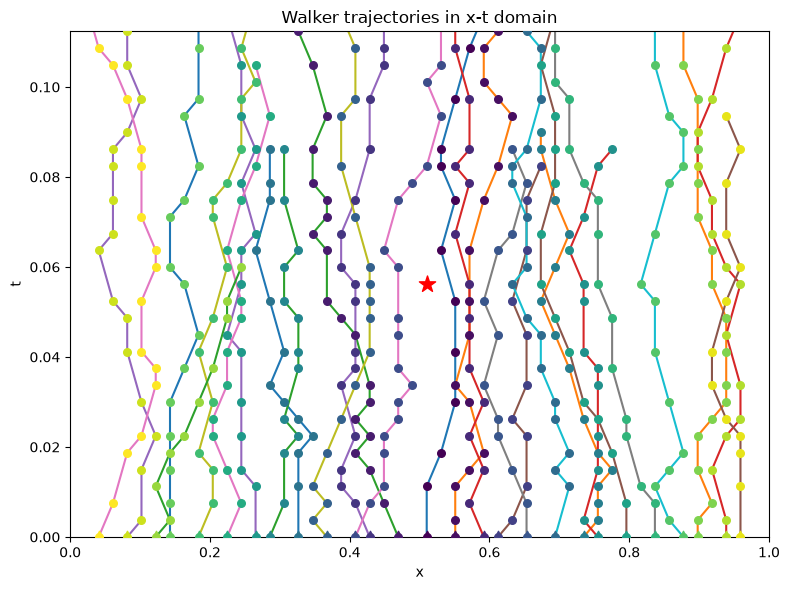

In [7]:
t_star_steps = 15  # ← change this to test different targets
env      = PDEEnvironment(t_star_steps=t_star_steps)
state, _ = env.reset()

trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}

done           = False
total_accepted = 0
total_rejected = {}

while not done:
    action = env.action_space.sample()
    state, reward, done, _, info = env.step(action)



    total_accepted += int(info['accepted'])
    if info['rejected']:
        reason = info['rejected']
        total_rejected[reason] = total_rejected.get(reason, 0) + 1

    if info['accepted']:
        i = info['walker']
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))

visited_log = [(x, t) for (x, t, _) in env.visited._pts
               if t > 0.0 and 0.0 < x < 1.0]

print(f"Steps:          {env.step_count}")
print(f"Reward:         {reward:.6f}")
print(f"Reached:        {info.get('reached', False)}")
print(f"Timeout:        {info.get('timeout', False)}")
print(f"Total accepted: {total_accepted}")
print(f"Total rejected: {sum(total_rejected.values())}")
print("Rejection reasons:")

for reason, count in sorted(total_rejected.items(), key=lambda kv: -kv[1]):
    print(f"  {reason:10s}: {count}")
# walker distribution check — tells you if one walker is dominating
walker_counts = {}
for i, traj in trajectories.items():
    walker_counts[i] = len(traj) - 1  # subtract starting position
print("\nAccepted moves per walker:")
for i, count in sorted(walker_counts.items()):
    print(f"  Walker {i:d}: {count}")

fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = plt.cm.viridis(np.linspace(0, 1, env.N))
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    ax.plot(xs, ts, '-', linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()

In [9]:
u_hat, ok, nb, reason = env._gfdm_solve(env.x_star, env.t_star)
print(reason, ok, u_hat)
print(nb)

ok True 0.0
[[1.         0.1835206 ]
 [1.         0.17977528]
 [1.         0.17602996]
 [1.         0.17228464]
 [1.         0.16853933]]


## Plot Trajactories


In [9]:
def plot_trajectories(model, t_star_steps, N_particles, lam, beta, K_max,
                       save=True, timestep=None, img_dir=".", label=None):
    env = PDEEnvironment(t_star_steps=t_star_steps, N_particles=N_particles,
                          lam=lam, beta=beta, K_max=K_max)
    obs, _ = env.reset()
    trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True, action_masks=env.action_masks())
        obs, reward, done, _, info = env.step(action)
        if info['accepted']:
            i = info['walker']
            trajectories[i].append((env.walker_x[i], env.walker_t[i]))

    visited_log = [(x, t) for (x, t, _) in env.visited._pts]
    fig, ax = plt.subplots(figsize=(8, 6))

    vx = [p[0] for p in visited_log]
    vt = [p[1] for p in visited_log]
    ax.scatter(vx, vt, s=4, color='lightgray', zorder=1)

    # ── Rejected positions ───────────────────────────────────────────────────
    rej_colors = {
        'bounds':    'blue',
        'collision': 'orange',
        'cond':      'purple',
        'weights':   'brown',
        'geometry':  'red',
        None:        'gray',
    }
    if env.rejected_history:
        from collections import defaultdict
        by_reason = defaultdict(list)
        for (rx, rt, reason) in env.rejected_history:
            by_reason[reason].append((rx, rt))
        for reason, pts in by_reason.items():
            ax.scatter([p[0] for p in pts], [p[1] for p in pts],
                       s=6, alpha=0.08, linewidths=0, zorder=1,
                       color=rej_colors.get(reason, 'gray'),
                       label=f'rej:{reason} ({len(pts)})')
    # ─────────────────────────────────────────────────────────────────────────

    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    for i, traj in trajectories.items():
        xs = [p[0] for p in traj]
        ts = [p[1] for p in traj]
        ax.plot(xs, ts, '-', linewidth=1.5, color=colors[i], zorder=2)
        ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
        ax.scatter(xs[0], ts[0], s=80, color=colors[i], marker='^', zorder=4)

    reached = info.get('reached', False)
    outcome = 'reached' if reached else 'timeout'

    # ── Stencil at z* ────────────────────────────────────────────────────────
    if reached:
        _, success, nb_coords, _ = env._gfdm_solve(env.x_star, env.t_star)
        if success and nb_coords is not None:
            for (nx_, nt_) in nb_coords:
                ax.plot([env.x_star, nx_], [env.t_star, nt_],
                        '--', color='red', linewidth=0.8,
                        alpha=0.7, zorder=5)
            ax.scatter(nb_coords[:, 0], nb_coords[:, 1],
                       s=40, color='red', zorder=6, alpha=0.7)

    ax.scatter(env.x_star, env.t_star, s=150, color='red', marker='*', zorder=7)
    ax.set_xlabel('x')
    ax.set_ylabel('t')

    title = f't_star={t_star_steps}·dt  |  {outcome}'
    if timestep is not None:
        title += f'  |  step {timestep:,}'
    if reached and info.get('error') is not None:
        title += f'  |  err={info["error"]:.2e}  |  k={info["k_term"]}'
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, env.t_star * 2)

    if env.rejected_history:
        ax.legend(fontsize=6, loc='upper left', markerscale=2)

    plt.tight_layout()

    if save:
        if label is not None:
            fname = f'traj_t{t_star_steps}dt_{label}_{outcome}.png'
        elif timestep is not None:
            fname = f'traj_t{t_star_steps}dt_{timestep//1000:05d}k_{outcome}.png'
        else:
            fname = f'traj_t{t_star_steps}dt_{outcome}.png'
        fig.savefig(os.path.join(img_dir, fname), dpi=120)
        plt.close(fig)
    else:
        plt.show()

In [10]:
class ReachedRateCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.buf       = []
        self.kterm_buf = []
        self.err_buf   = []

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if info.get('reached'):
                self.buf.append(1)
                k = info.get('k_term')
                e = info.get('error')
                if k is not None and e is not None:
                    self.kterm_buf.append(k)
                    self.err_buf.append(e)
            elif info.get('timeout'):
                self.buf.append(0)
        if self.buf:
            self.logger.record('rollout/reached_rate',
                               sum(self.buf[-100:]) / len(self.buf[-100:]))
        if self.kterm_buf:
            self.logger.record('rollout/mean_kterm_on_reach',
                               np.mean(self.kterm_buf[-100:]))
            self.logger.record('rollout/mean_error_on_reach',
                               np.mean(self.err_buf[-100:]))
        return True

In [11]:
class PlotCallback(BaseCallback):
    def __init__(self, t_star_steps, N_particles, lam, beta, K_max, plot_freq=50_000, img_dir=".", verbose=0):
        super().__init__(verbose)
        self.t_star_steps = t_star_steps
        self.N_particles  = N_particles
        self.lam          = lam
        self.beta         = beta
        self.K_max        = K_max
        self.plot_freq    = plot_freq
        self.last_plot_at = 0
        self.img_dir      = img_dir

    def _on_step(self) -> bool:
        if self.num_timesteps - self.last_plot_at >= self.plot_freq:
            self.last_plot_at = self.num_timesteps
            plot_trajectories(self.model, self.t_star_steps, self.N_particles,
                              self.lam, self.beta, self.K_max, save=True,
                              timestep=self.num_timesteps, img_dir=self.img_dir)
        return True

def make_env(t_star_schedule, N_particles, lam, beta, K_max):
    def _init():
        env = PDEEnvironment(t_star_schedule=t_star_schedule, N_particles=N_particles,
                             lam=lam, beta=beta, K_max=K_max)
        env = ActionMasker(env, lambda e: e.action_masks())
        return Monitor(env)
    return _init

In [ ]:
# ── Run configuration ────────────────────────────────────────────────────────
N_particles     = 26
t_star_schedule = {5: 120} #, 7: 140, 10: 200, 15: 300}   # {t_star_steps: K_max}
seeds           = [52]
lam             = 0.01
beta            = 10000
n_envs          = 15
n_steps         = 2048 // n_envs
total_timesteps = 1_000_000

# representative t* used ONLY for periodic plots/videos (policy trains on all keys)
plot_tstar   =5
plot_K_max   = t_star_schedule[plot_tstar]

# ── Run directory ────────────────────────────────────────────────────────────
day        = date.today().day
stages_str = "-".join(str(s) for s in t_star_schedule.keys())
run_name   = f"t{stages_str}_lam{lam}_beta{beta}_N{N_particles}"
run_dir    = os.path.join(f"runs{day}", run_name)

print(f"Run: {run_dir}")
print(f"Training jointly on t*={list(t_star_schedule.keys())}  "
      f"(periodic plots shown at t*={plot_tstar})")

for seed in seeds:

    seed_dir  = os.path.join(run_dir, f"seed{seed}")
    img_dir   = os.path.join(seed_dir, "images")
    ckpt_dir  = os.path.join(seed_dir, "checkpoints")

    os.makedirs(img_dir,  exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)

    print(f"\n{'#'*50}\nSEED {seed}\n{'#'*50}")

    # every subprocess gets the SAME schedule and resamples t* per episode in reset()
    vec_env = SubprocVecEnv([
        make_env(t_star_schedule, N_particles, lam, beta, K_max=None)
        for _ in range(n_envs)
    ])

    model = MaskablePPO(
        "MlpPolicy",
        vec_env,
        verbose=1,
        seed=seed,
        tensorboard_log=os.path.join(seed_dir, "logs"),
        learning_rate=5e-4,
        clip_range=0.1,
        n_steps=n_steps,
        batch_size=60,
        gamma=1.0,
        ent_coef=0.01,
        device="cpu",
    )

    print(f"\n{'='*50}")
    print(f"Joint training over t* schedule: {t_star_schedule}")
    print(f"budget: {total_timesteps//1000}k steps")
    print(f"{'='*50}")

    model.learn(
        total_timesteps=total_timesteps,
        reset_num_timesteps=False,
        tb_log_name=f"seed{seed}",
        log_interval=10,
        callback=[
            ReachedRateCallback(),
            PlotCallback(plot_tstar, N_particles, lam, beta, plot_K_max,
                         plot_freq=100_000, img_dir=img_dir),
            CheckpointCallback(
                save_freq=100_000,
                save_path=os.path.join(ckpt_dir, "sched"),
                name_prefix="sched"
            ),
        ],
    )

    model.save(os.path.join(ckpt_dir, "sched_final"))

    # final plots/videos at the representative t*
    plot_trajectories(model, plot_tstar, N_particles, lam, beta, plot_K_max,
                      save=True, timestep=None, img_dir=img_dir, label="final")
    make_trajectory_video2(img_dir, plot_tstar, N_particles, lam, beta, plot_K_max,
                           label="final", fps=5)
    make_training_progress_video(img_dir, plot_tstar, N_particles, lam, beta, plot_K_max,
                                 label="final", fps=5)

Run: runs15\t5_lam0.01_beta10000_N26
Training jointly on t*=[5]  (periodic plots shown at t*=5)

##################################################
SEED 52
##################################################
Using cpu device

Joint training over t* schedule: {5: 120}
budget: 1000k steps
Logging to runs15\t5_lam0.01_beta10000_N26\seed52\logs\seed52_0
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 104         |
|    ep_rew_mean          | -1.83       |
|    mean_error_on_reach  | 1.55e-05    |
|    mean_kterm_on_reach  | 52.7        |
|    reached_rate         | 0.25        |
| time/                   |             |
|    fps                  | 1674        |
|    iterations           | 10          |
|    time_elapsed         | 12          |
|    total_timesteps      | 20400       |
| train/                  |             |
|    approx_kl            | 0.014751794 |
|    clip_fraction        | 0.527       |
|    clip_range    

### Only run the following cell if you wanna add more training episodes


In [ ]:
# ── Resume configuration ──────────────────────────────────────────────────────
additional_timesteps = 5_000_000   # <-- set how many MORE steps you want; not a new grand total
resume_seed           = seeds[0]
resume_stage          = curriculum[0]

seed_dir  = os.path.join(run_dir, f"seed{resume_seed}")
img_dir   = os.path.join(seed_dir, "images")
ckpt_dir  = os.path.join(seed_dir, "checkpoints")

checkpoint_path = os.path.join(ckpt_dir, f"tstar{resume_stage}_final")
print(f"Resuming from: {checkpoint_path}.zip")
print(f"Config being reused: N_particles={N_particles}, lam={lam}, beta={beta}, K_max={K_max}, t_star_steps={resume_stage}")

vec_env = SubprocVecEnv([make_env(resume_stage, N_particles, lam, beta, K_max)
                         for _ in range(n_envs)])

model = MaskablePPO.load(
    checkpoint_path,
    env=vec_env,
    tensorboard_log=os.path.join(seed_dir, "logs"),
)
print(f"Loaded model at num_timesteps = {model.num_timesteps:,}")

model.learn(
    total_timesteps=additional_timesteps,
    reset_num_timesteps=False,          # critical -- continues the step count, doesn't restart it
    tb_log_name=f"seed{resume_seed}",   # SAME name as the original run -> continues the same TB curve
    log_interval=10,
    callback=[
        ReachedRateCallback(),
        PlotCallback(resume_stage,  N_particles, lam, beta, K_max, plot_freq=100_000, img_dir=img_dir),
        CheckpointCallback(
            save_freq=100_000,
            save_path=os.path.join(ckpt_dir, f"tstar{resume_stage}"),
            name_prefix=f"tstar{resume_stage}"
        ),
    ],
)

print(f"Done. num_timesteps now = {model.num_timesteps:,}")

# saved under a DIFFERENT name on purpose -- keeps the original "_final" checkpoint
# intact as a fallback in case this continued run doesn't actually improve things
model.save(os.path.join(ckpt_dir, f"tstar{resume_stage}_final_continued"))

plot_trajectories(
    model, resume_stage, N_particles, lam, beta, K_max,
    save=True, timestep=None, img_dir=img_dir, label="final_continued")

      
make_training_progress_video(img_dir=img_dir, t_star_steps=resume_stage, fps=3)

Resuming from: runs14\t10_lam0.01_beta10000_K200_N26\seed5\checkpoints\tstar10_final.zip
Config being reused: N_particles=26, lam=0.01, beta=10000, K_max=200, t_star_steps=10
Loaded model at num_timesteps = 3,000,840
Logging to runs14\t10_lam0.01_beta10000_K200_N26\seed5\logs\seed5_0
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 14.3        |
|    ep_rew_mean          | -0.513      |
|    mean_error_on_reach  | 3.71e-05    |
|    mean_kterm_on_reach  | 14.3        |
|    reached_rate         | 1           |
| time/                   |             |
|    fps                  | 1716        |
|    iterations           | 10          |
|    time_elapsed         | 11          |
|    total_timesteps      | 3021240     |
| train/                  |             |
|    approx_kl            | 0.003290676 |
|    clip_fraction        | 0.175       |
|    clip_range           | 0.1         |
|    entropy_loss         | -1.01       |
|

'runs14\\t10_lam0.01_beta10000_K200_N26\\seed5\\images\\traj_t10dt_training_progress.mp4'

In [ ]:
import importlib
import trajectory_video2
importlib.reload(trajectory_video2)
from trajectory_video2 import make_trajectory_video1

make_trajectory_video1(
    model,              # your trained MaskablePPO model
    PDEEnvironment,     # the class itself, not an instance
    t_star_steps,       # e.g. 10
    N_particles,        # e.g. 26 — must match what the model was trained on
    img_dir=img_dir,    # same folder you pass to plot_trajectories
    label="final",      # goes into the output filename
    )

Rollout done: reached, 13 accepted points, 13 total steps.
Saved video: runs14\t10_lam0.01_beta10000_K200_N26\seed5\images\traj_t10dt_final_reached.mp4


'runs14\\t10_lam0.01_beta10000_K200_N26\\seed5\\images\\traj_t10dt_final_reached.mp4'

## Test the policy on different t*


── test t*=20·dt  (K_max=240)  [OUT-of-schedule (extrapolation)] ──
  steps=240  reward=-3.400000
  reached=False  timeout=True  error=None
  accepted=91  rejected=149
    bounds_u  : 149
  dt_rel visited: min=-20.0  max=10.0  (training floor for this t* is -20)


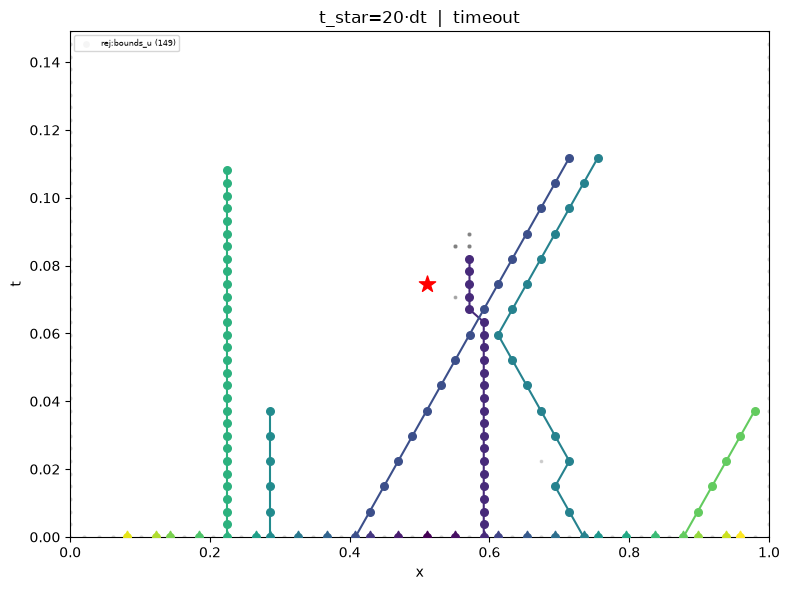

: 

In [ ]:
# ── Pick any t* and see its plot + diagnostics ───────────────────────────────
CHOOSE_TSTAR =20          # ← the only thing you edit

def test_at_tstar(model, t_star_steps_test, N_particles, lam, beta, K_max_test,
                  deterministic=True):
    """Evaluate `model` at a chosen t*. Fixed-t* env (schedule=None) so the
    horizon is exactly what you asked for. Passes all hyperparameters explicitly."""
    env = PDEEnvironment(t_star_schedule=None, t_star_steps=t_star_steps_test,
                         N_particles=N_particles, lam=lam, beta=beta, K_max=K_max_test)
    obs, _ = env.reset()

    total_accepted = 0
    total_rejected = {}
    dt_rel_hist = []
    done = False
    while not done:
        masks = env.action_masks()
        action, _ = model.predict(obs, action_masks=masks, deterministic=deterministic)
        obs, reward, done, _, info = env.step(action)
        dt_rel_hist.append((env.walker_t.copy() - env.t_star) / env.dt)
        total_accepted += int(info['accepted'])
        if info['rejected']:
            r = info['rejected']; total_rejected[r] = total_rejected.get(r, 0) + 1

    in_sched = t_star_steps_test in t_star_schedule
    tag = "IN-schedule" if in_sched else "OUT-of-schedule (extrapolation)"
    print(f"── test t*={t_star_steps_test}·dt  (K_max={K_max_test})  [{tag}] ──")
    print(f"  steps={env.step_count}  reward={reward:.6f}")
    print(f"  reached={info.get('reached', False)}  timeout={info.get('timeout', False)}"
          f"  error={info.get('error')}")
    print(f"  accepted={total_accepted}  rejected={sum(total_rejected.values())}")
    for r, c in sorted(total_rejected.items(), key=lambda kv: -kv[1]):
        print(f"    {r:10s}: {c}")
    if dt_rel_hist:
        arr = np.concatenate(dt_rel_hist)
        print(f"  dt_rel visited: min={arr.min():.1f}  max={arr.max():.1f}  "
              f"(training floor for this t* is -{t_star_steps_test})")

    # reuse existing plotter, don't save → renders inline
    # (requires plot_trajectories to plt.show() when save=False instead of plt.close)
    plot_trajectories(model, t_star_steps_test, N_particles,
                      lam, beta, K_max_test, save=False)
    return info

info = test_at_tstar(model, t_star_steps_test=CHOOSE_TSTAR,
                     N_particles=N_particles, lam=lam, beta=beta,
                     K_max_test=t_star_schedule.get(CHOOSE_TSTAR, 240))